In [1]:
import pandas as pd
import json
from pandas import json_normalize
import os

In [25]:
with open('categorized_tasks-gpt-4o-gpt-4o-retail.json', 'r') as f:
    data = json.load(f)
df = json_normalize(
    data,
    record_path=["conversations"],
    meta=["Task id"],  # bring parent key along
)
df.head()

,intent,conversation_segment,category,reasoning,Task id
0,EXCHANGE_ORDER,User: Hello! I recently received an order and ...,procedural,The conversation is procedural because the use...,0
1,EXCHANGE_ORDER,User: Hello! I recently received an order and ...,procedural,The conversation is procedural because the use...,1
2,RETURN_ORDER,User: Thanks for the information! I also need ...,procedural,The conversation is procedural because the use...,2
3,MODIFY_ORDER,User: Thanks for the information. I have some ...,procedural,The conversation is procedural because the use...,3
4,MODIFY_ORDER,User: Thanks for the details. I have some pend...,procedural,The conversation is procedural because the use...,4


In [27]:
df[["Task id", "intent","conversation_segment","category"]].to_csv("csv's/categorized_tasks-gpt-4o-gpt-4o-retail.csv", index=False)


In [7]:
df[df["Task id"] == 104]

,intent,conversation_segment,category,reasoning,Task id
162,CANCEL_ORDER,User: Hi there! I'd like to cancel two things ...,declarative,The conversation is declarative because the us...,104
163,RETURN_ORDER,"User: Yes, I’d like to return both the bookshe...",procedural,The conversation is procedural because the use...,104
164,MODIFY_ADDRESS,"User: Got it, no worries! I’d also like to cha...",procedural,The conversation is procedural because the use...,104
165,MODIFY_ORDER,User: Awesome! Could you also change the color...,declarative,The conversation is declarative because the us...,104


In [30]:
df_counts = df.groupby(["Task id", "category"]) \
.size()  \
.unstack(fill_value=0)  \
.reset_index()
df_counts

category,Task id,declarative,procedural
0,0,0,1
1,1,0,1
2,2,0,1
3,3,0,1
4,4,0,1
...,...,...,...
107,110,1,2
108,111,2,1
109,112,1,2
110,113,1,2


In [39]:
df_counts["sub_tasks"] = df_counts["procedural"] + df_counts["declarative"]
df_counts["procedural_ratio"] =  df_counts["procedural"] / df_counts["sub_tasks"]
df_counts["declarative_ratio"] =  df_counts["declarative"] / df_counts["sub_tasks"]
df_counts.to_csv("csv's/task_category_counts_ratio-gpt-4o-gpt-4o-retail.csv", index=False)

In [40]:
df_tasks_counts = df.groupby(["intent", "category"]) \
.size()  \
.unstack(fill_value=0)  \
.reset_index()
df_tasks_counts

category,intent,declarative,procedural
0,CANCEL_ORDER,9,22
1,EXCHANGE_ORDER,25,31
2,MODIFY_ADDRESS,4,22
3,MODIFY_ORDER,14,24
4,RETURN_ORDER,7,30


In [41]:
df_tasks_counts.to_csv("csv's/task_category_counts-gpt-4o-gpt-4o-retail.csv", index=False)

In [42]:
grouped = df.groupby(["intent", "category"])
_df_tasks_counts = grouped.size().reset_index(name="count")
df_taskids = grouped["Task id"].apply(list).reset_index(name="task_ids")
df_tasks_counts_withids = _df_tasks_counts.merge(df_taskids, on=["intent", "category"], how="left")
df_tasks_counts_withids

,intent,category,count,task_ids
0,CANCEL_ORDER,declarative,9,"[31, 33, 34, 36, 50, 57, 63, 104, 105]"
1,CANCEL_ORDER,procedural,22,"[13, 16, 24, 28, 30, 31, 32, 32, 38, 54, 59, 6..."
2,EXCHANGE_ORDER,declarative,25,"[5, 6, 7, 8, 9, 20, 21, 30, 35, 52, 54, 65, 77..."
3,EXCHANGE_ORDER,procedural,31,"[0, 1, 18, 19, 23, 23, 27, 29, 29, 41, 44, 45,..."
4,MODIFY_ADDRESS,declarative,4,"[26, 86, 105, 111]"
5,MODIFY_ADDRESS,procedural,22,"[17, 22, 22, 33, 34, 39, 41, 42, 43, 59, 71, 7..."
6,MODIFY_ORDER,declarative,14,"[10, 24, 36, 37, 38, 42, 47, 66, 81, 88, 90, 9..."
7,MODIFY_ORDER,procedural,24,"[3, 4, 15, 21, 22, 23, 35, 36, 40, 60, 61, 62,..."
8,RETURN_ORDER,declarative,7,"[11, 12, 25, 26, 33, 69, 82]"
9,RETURN_ORDER,procedural,30,"[2, 10, 14, 16, 18, 19, 27, 28, 30, 30, 31, 32..."


In [43]:
df_tasks_counts_withids.to_csv("csv's/task_category_counts_withids-gpt-4o-gpt-4o-retail.csv", index=False)

In [44]:
df_counts["procedural_flag"] = df_counts["procedural"].apply(lambda x: "yes" if x > 0 else "no")
df_counts["declarative_flag"] = df_counts["declarative"].apply(lambda x: "yes" if x > 0 else "no")
df_counts["sub_tasks"] = df_counts["procedural"] + df_counts["declarative"]

In [45]:
df_counts[df_counts["sub_tasks"] == 4]

category,Task id,declarative,procedural,sub_tasks,procedural_ratio,declarative_ratio,procedural_flag,declarative_flag
30,30,1,3,4,0.75,0.25,yes,yes
101,104,2,2,4,0.50,0.50,yes,yes
102,105,2,2,4,0.50,0.50,yes,yes


In [46]:
df[df["Task id"]==104]

,intent,conversation_segment,category,reasoning,Task id
162,CANCEL_ORDER,User: Hi there! I'd like to cancel two things ...,declarative,The conversation is declarative because the us...,104
163,RETURN_ORDER,"User: Yes, I’d like to return both the bookshe...",procedural,The conversation is procedural because the use...,104
164,MODIFY_ADDRESS,"User: Got it, no worries! I’d also like to cha...",procedural,The conversation is procedural because the use...,104
165,MODIFY_ORDER,User: Awesome! Could you also change the color...,declarative,The conversation is declarative because the us...,104


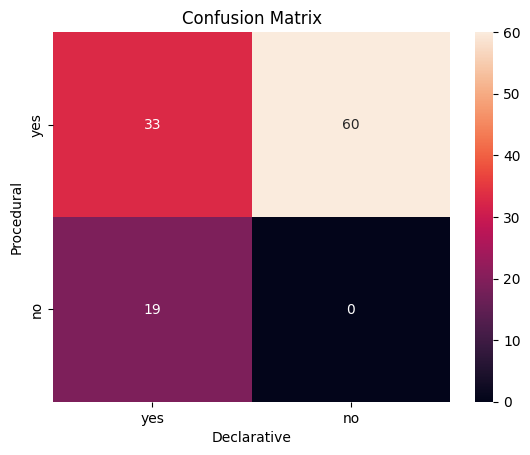

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(df_counts['procedural_flag'], df_counts['declarative_flag'], labels=['yes', 'no'])

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['yes', 'no'], yticklabels=['yes', 'no'])
plt.xlabel('Declarative')
plt.ylabel('Procedural')
plt.title('Confusion Matrix')
plt.show()